# Modeling

In [1]:
# import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_clean = pd.read_csv("/Users/clarabaptista/Documents/10_PERSO/DATA/PROJECTS/Music-recommendation-system/data/data_clean.csv")
df_clean.head(3)

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339


In [3]:
df_clean.columns.values

array(['valence', 'year', 'acousticness', 'artists', 'danceability',
       'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness',
       'key', 'liveness', 'loudness', 'mode', 'name', 'popularity',
       'release_date', 'speechiness', 'tempo'], dtype=object)

<Axes: >

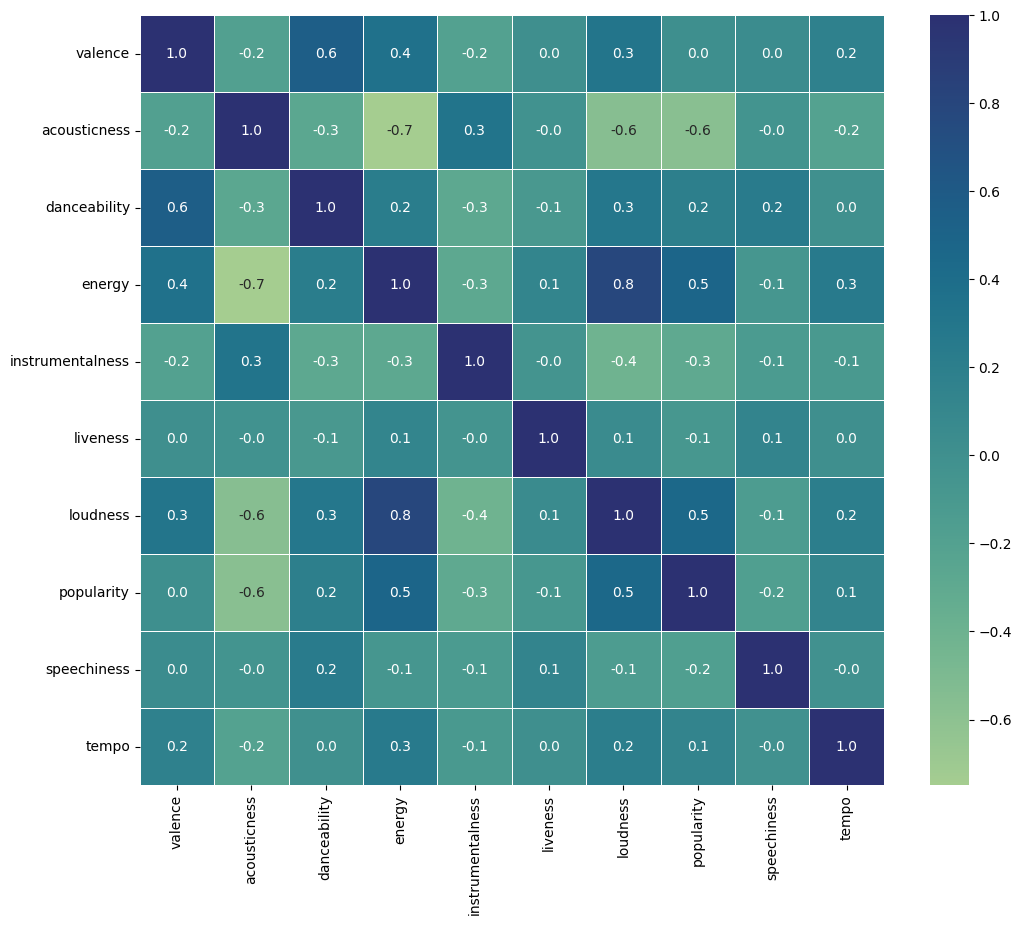

In [4]:
features = ['valence', 'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'popularity', 'speechiness', 'tempo']

plt.figure(figsize = (12,10))
# plt.rcParams.update({'font.size': 12})
sns.heatmap(df_clean[features].corr(), annot=True, fmt=".1f", linewidths=.5, cmap="crest")

In [5]:
from sklearn.preprocessing import StandardScaler
# X = df[features].fillna(0).values
X = df_clean[features]
# scaler = StandardScaler().fit(X)
# X_scaled = scaler.transform(X)
X_scaled = StandardScaler().fit_transform(X)

In [9]:
from sklearn.neighbors import NearestNeighbors

nneighbors = NearestNeighbors(n_neighbors=11, metric='cosine').fit(X_scaled)
distances, indices = nneighbors.kneighbors(X_scaled)

In [26]:
def recommendation_by_index(i, topk=10):
    if topk > nneighbors.n_neighbors-1:
        raise ValueError(f"topk must be <= {nneighbors.n_neighbors-1}.")
    nneighbor_indices = indices[i][i:topk+1]
    return df_clean.iloc[nneighbor_indices][['name', 'artists']]
    
print(recommendation_by_index(8, topk=6))

Empty DataFrame
Columns: [name, artists]
Index: []


In [27]:
def recommendation_by_name(song_name, topk=10):
    if topk > nneighbors.n_neighbors-1:
        raise ValueError(f"topK must be <= {nneighbors.n_neighbors-1}.")
    # TODO: Pourquoi index 0 ?
    i = df_clean[df_clean['name'] == song_name].index[0]
    return recommendation_by_index(i, topk)

recommendation_by_name("Shape of You", topk=10)

,name,artists
